In [69]:
# Importação das bibliotecas utilizadas

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from scipy.io import arff

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ( accuracy_score, classification_report, confusion_matrix, roc_curve, auc )

In [70]:
!wget -O asd_children.zip "https://archive.ics.uci.edu/static/public/419/autistic+spectrum+disorder+screening+data+for+children.zip"
!unzip -o asd_children.zip

# Download e carregamento da base pública do UCI
data, meta = arff.loadarff('Autism-Child-Data.arff')
df = pd.DataFrame(data)

# Conversão de variáveis categóricas (bytes para string)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.decode('utf-8')

df.head()

--2026-08-26 14:02:39--  https://archive.ics.uci.edu/static/public/419/autistic+spectrum+disorder+screening+data+for+children.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘asd_children.zip’

asd_children.zip        [ <=>                ]  39.14K  --.-KB/s    in 0.02s   

2026-08-26 14:02:39 (1.74 MB/s) - ‘asd_children.zip’ saved [40081]

Archive:  asd_children.zip
  inflating: Autism-Child-Data.arff  
  inflating: Autism-Screening-Child-Data Description.docx  


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,...,m,Others,no,no,Jordan,no,5.0,4-11 years,Parent,NO
1,1,1,0,0,1,1,0,1,0,0,...,m,Middle Eastern,no,no,Jordan,no,5.0,4-11 years,Parent,NO
2,1,1,0,0,0,1,1,1,0,0,...,m,?,no,no,Jordan,yes,5.0,4-11 years,?,NO
3,0,1,0,0,1,1,0,0,0,1,...,f,?,yes,no,Jordan,no,4.0,4-11 years,?,NO
4,1,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10.0,4-11 years,Parent,YES


In [71]:
# Conversão da variável alvo para formato binário

df['Class/ASD'] = df['Class/ASD'].map({'NO': 0, 'YES': 1})
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,151
1,141


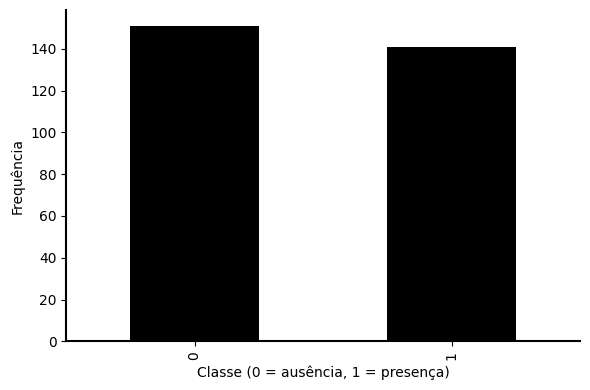

In [72]:
plt.figure(figsize=(6,4))
df["Class/ASD"].value_counts().sort_index().plot(kind="bar", color="black")

plt.xlabel("Classe (0 = ausência, 1 = presença)")
plt.ylabel("Frequência")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig1.png", dpi=300)
plt.show()

In [73]:
# Separação entre variáveis explicativas e variável alvo

X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]

# Transformação de variáveis categóricas (one-hot encoding)

X = pd.get_dummies(X, drop_first=True)
X = X.drop("result", axis=1, errors="ignore")
# Remoção da coluna redundante 'result', quando presente
X = X.fillna(0)

# Divisão em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (204, 81)
Teste: (88, 81)


In [74]:
# Treinamento da Regressão Logística

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predições e probabilidades

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy Logística:", model.score(X_test, y_test))
print(classification_report(y_test, y_pred))

Accuracy Logística: 0.9886363636363636
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        51
           1       1.00      0.97      0.99        37

    accuracy                           0.99        88
   macro avg       0.99      0.99      0.99        88
weighted avg       0.99      0.99      0.99        88



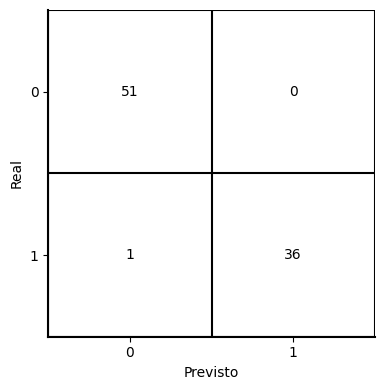

In [75]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
ax = plt.gca()
ax.set_facecolor("white")
plt.gcf().patch.set_facecolor("white")
plt.imshow(np.ones_like(cm), cmap="gray", vmin=0, vmax=1)
for i in range(3):
    ax.axhline(i-0.5, color='black', linewidth=1.5)
    ax.axvline(i-0.5, color='black', linewidth=1.5)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
plt.xlabel("Previsto")
plt.ylabel("Real")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.grid(False)

plt.tight_layout()
plt.savefig("fig2.png", dpi=300, facecolor="white")
plt.show()

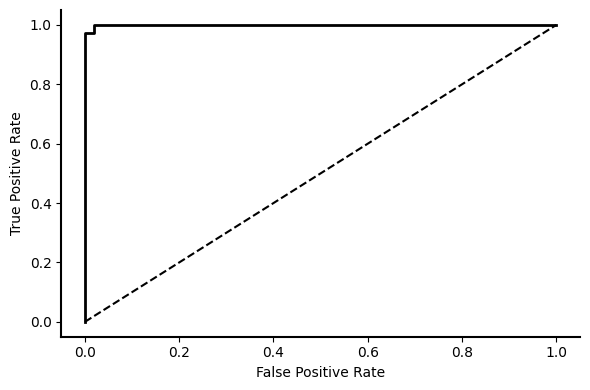

AUC Logística: 0.9994700582935877


In [76]:

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr_lr, tpr_lr, color="black", linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig3.png", dpi=300)
plt.show()

print("AUC Logística:", auc_lr)

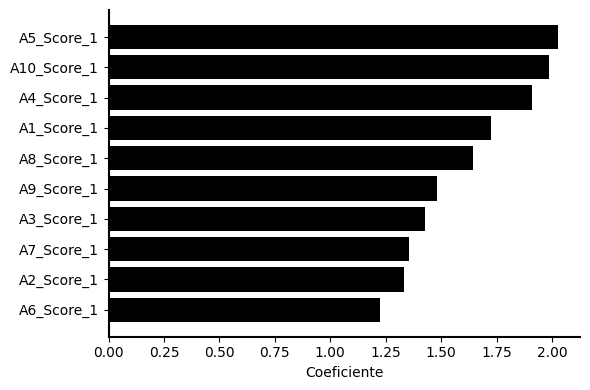

In [77]:
coef = model.coef_[0]
features = X.columns

coef_df = pd.DataFrame({
    "Variável": features,
    "Coeficiente": coef
})

coef_df["Importância"] = np.abs(coef_df["Coeficiente"])
coef_df = coef_df.sort_values("Importância", ascending=False)

top = coef_df.head(10)

plt.figure(figsize=(6,4))
plt.barh(top["Variável"], top["Coeficiente"], color="black")

plt.xlabel("Coeficiente")
plt.gca().invert_yaxis()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.tight_layout()
plt.savefig("fig4.png", dpi=300)
plt.show()

In [78]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy Random Forest:", rf.score(X_test, y_test))
print(classification_report(y_test, rf_pred))

Accuracy Random Forest: 0.9090909090909091
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        51
           1       0.85      0.95      0.90        37

    accuracy                           0.91        88
   macro avg       0.91      0.91      0.91        88
weighted avg       0.91      0.91      0.91        88



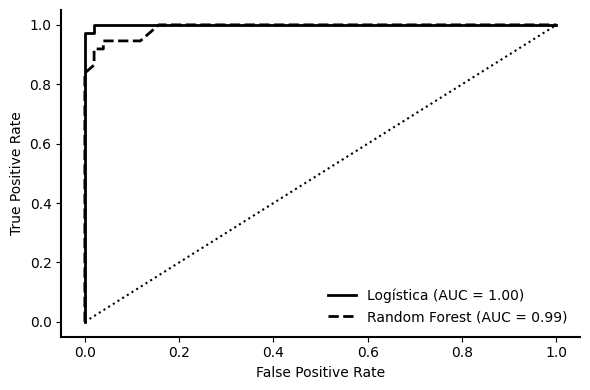

In [79]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,4))

plt.plot(fpr_lr, tpr_lr, color="black", linewidth=2, linestyle="-")
plt.plot(fpr_rf, tpr_rf, color="black", linewidth=2, linestyle="--")
plt.plot([0,1],[0,1], linestyle=":", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.grid(False)

plt.legend([
    f"Logística (AUC = {auc_lr:.2f})",
    f"Random Forest (AUC = {auc_rf:.2f})"
], frameon=False)

plt.tight_layout()
plt.savefig("fig5.png", dpi=300)
plt.show()

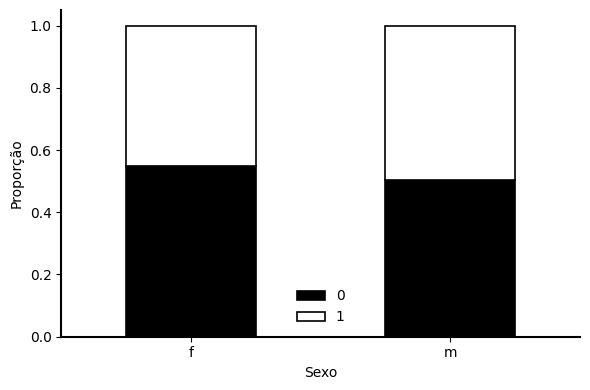

In [80]:
tab = pd.crosstab(df["gender"], df["Class/ASD"], normalize="index")

plt.style.use("default")
plt.figure(figsize=(6,4))

ax = plt.gca()
ax.set_facecolor("white")
plt.gcf().patch.set_facecolor("white")
tab.plot(kind="bar",
         stacked=True,
         color=["black","white"],
         edgecolor="black",
         linewidth=1.2,
         ax=ax)

plt.xlabel("Sexo")
plt.ylabel("Proporção")
plt.xticks(rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color("black")
ax.spines['bottom'].set_color("black")

ax.grid(False)
plt.legend(frameon=False)

plt.tight_layout()
plt.savefig("fig6.png", dpi=300, facecolor="white")
plt.show()

In [81]:
# Teste Qui-quadrado para verificar associação entre sexo e classificação

from scipy.stats import chi2_contingency


tab_abs = pd.crosstab(df["gender"], df["Class/ASD"])

chi2, p, dof, expected = chi2_contingency(tab_abs)

print("Qui-quadrado:", chi2)
print("p-valor:", p)

Qui-quadrado: 0.28447044555963774
p-valor: 0.5937859868520012


In [82]:
# Construção da tabela de contingência absoluta entre
# histórico familiar ("austim") e classificação final ("Class/ASD")
tab_hist = pd.crosstab(df["austim"], df["Class/ASD"])

# Construção da tabela proporcional por linha (percentual dentro de cada grupo)
# O parâmetro normalize="index" calcula proporções relativas ao total de cada categoria de histórico familiar
tab_hist_pct = pd.crosstab(
    df["austim"],
    df["Class/ASD"],
    normalize="index"
) * 100

tab_hist
tab_hist_pct

Class/ASD,0,1
austim,,
no,50.617284,49.382716
yes,57.142857,42.857143


In [83]:
# Teste Qui-quadrado de independência entre histórico familiar e classificação final

chi2, p, dof, expected = chi2_contingency(tab_hist)


print("Qui-quadrado:", chi2)
print("p-valor:", p)

Qui-quadrado: 0.4586096156884319
p-valor: 0.4982744889440034


In [84]:
# Construção de um novo conjunto de variáveis explicativas
# removendo qualquer coluna relacionada ao histórico familiar
X_sem_hist = X.drop(
    columns=[col for col in X.columns if "austim" in col]
)

# Nova divisão em treino e teste, mantendo os mesmos parâmetros
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_sem_hist,
    y,
    test_size=0.3,
    random_state=42
)

# Treinamento de nova Regressão Logística sem histórico familiar
model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train2, y_train2)

# Cálculo das probabilidades previstas
y_prob2 = model2.predict_proba(X_test2)[:, 1]

# Cálculo da curva ROC e da AUC
fpr2, tpr2, _ = roc_curve(y_test2, y_prob2)
auc2 = auc(fpr2, tpr2)

# Comparação entre os modelos
print("AUC sem histórico:", auc2)
print("AUC com histórico:", auc_lr)

AUC sem histórico: 0.9994700582935877
AUC com histórico: 0.9994700582935877


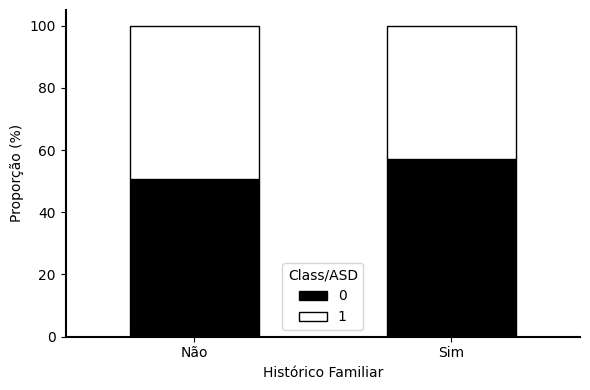

In [85]:
tab_hist_pct = pd.crosstab(
    df["austim"],
    df["Class/ASD"],
    normalize="index"
) * 100

fig, ax = plt.subplots(figsize=(6,4))

tab_hist_pct.plot(
    kind="bar",
    stacked=True,
    color=["black", "white"],
    edgecolor="black",
    ax=ax
)

ax.set_xlabel("Histórico Familiar")
ax.set_ylabel("Proporção (%)")
ax.set_xticklabels(["Não", "Sim"], rotation=0)

ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig("fig_hist_familiar.png", dpi=300, facecolor="white")
plt.show()

In [86]:
# Selecionar apenas as 10 variáveis do AQ-10
aq10_cols = [col for col in df.columns if "A" in col and "_Score" in col]

X_aq10 = df[aq10_cols]
y = df["Class/ASD"]

# Separação treino/teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_aq10, y, test_size=0.3, random_state=42
)

# Treinar modelo logístico simplificado
from sklearn.linear_model import LogisticRegression

model_aq10 = LogisticRegression(max_iter=1000)
model_aq10.fit(X_train, y_train)

print("Accuracy (Modelo Simplificado):", model_aq10.score(X_test, y_test))

Accuracy (Modelo Simplificado): 1.0


In [87]:
coeficientes_reais = model_aq10.coef_[0]
intercept_real = model_aq10.intercept_[0]

coef_df_real = pd.DataFrame({
    "Variável": aq10_cols,
    "Coeficiente": coeficientes_reais
})

coef_df_real

,Variável,Coeficiente
0,A1_Score,1.783907
1,A2_Score,1.368032
2,A3_Score,1.470703
3,A4_Score,1.935939
4,A5_Score,2.044535
5,A6_Score,1.228392
6,A7_Score,1.412613
7,A8_Score,1.737710
8,A9_Score,1.583022
9,A10_Score,2.052199


In [88]:
print(model_aq10.intercept_[0])

-10.672538874097201


In [89]:
coeficientes = [
    1.783907,
    1.368032,
    1.470703,
    1.935939,
    2.044535,
    1.228392,
    1.412613,
    1.737710,
    1.583022,
    2.052199
]

intercept = -10.672538874097201

In [90]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import math

perguntas = [
    "A1. Foca mais em detalhes do que no todo?",
    "A2. Dificuldade em entender o ponto de vista alheio?",
    "A3. Prefere fazer as coisas da mesma forma sempre?",
    "A4. Gosta de planejar atividades cuidadosamente?",
    "A5. Fica muito focado em padrões e números?",
    "A6. Nota detalhes que os outros não percebem?",
    "A7. Dificuldade em saber as intenções dos outros?",
    "A8. Dificuldade em ler as entrelinhas?",
    "A9. Fica ansioso em situações sociais novas?",
    "A10. Dificuldade em fazer novos amigos?"
]

seletores = []
for p in perguntas:
    seletores.append(
        widgets.Dropdown(
            options=['Não', 'Sim'],
            value='Não',
            layout=widgets.Layout(width='100px')
        )
    )

titulo = HTML("<h2>Termômetro de Triagem: Indícios de TEA (Regressão Logística)</h2><hr>")
botao = widgets.Button(description="Processar Avaliação", button_style='info', icon='stethoscope')
saida = widgets.Output()

coluna_esq = widgets.VBox([
    widgets.HBox([widgets.Label(perguntas[i], layout=widgets.Layout(width='350px')), seletores[i]])
    for i in range(5)
])

coluna_dir = widgets.VBox([
    widgets.HBox([widgets.Label(perguntas[i], layout=widgets.Layout(width='350px')), seletores[i]])
    for i in range(5, 10)
])

formulario = widgets.HBox([coluna_esq, coluna_dir])

def calcular_risco(b):
    with saida:
        clear_output()

        respostas_num = [1 if s.value == 'Sim' else 0 for s in seletores]

        coeficientes = [
            1.783907,
            1.368032,
            1.470703,
            1.935939,
            2.044535,
            1.228392,
            1.412613,
            1.737710,
            1.583022,
            2.052199
        ]

        intercept = -10.672538874097201

        pontuacao_total = intercept + sum(r * c for r, c in zip(respostas_num, coeficientes))
        probabilidade = 1 / (1 + math.exp(-pontuacao_total))
        prob_percentual = int(probabilidade * 100)

        if prob_percentual < 40:
            cor = "#28a745"
            mensagem = "<h3 style='color: #28a745;'>[Risco Baixo] Sinais mínimos. Acompanhamento padrão.</h3>"
        elif prob_percentual < 70:
            cor = "#ffc107"
            mensagem = "<h3 style='color: #d39e00;'>[Risco Moderado] Sinais presentes. Observação recomendada.</h3>"
        else:
            cor = "#dc3545"
            mensagem = "<h3 style='color: #dc3545;'>[ALERTA MÉDICO] Sugere-se encaminhamento prioritário para especialista!</h3>"

        html_resultado = f"""
        <br>
        <div style="width: 80%; background-color: #e0e0e0; border-radius: 10px; border: 1px solid #ccc;">
          <div style="width: {prob_percentual}%; background-color: {cor}; padding: 10px 0; color: white; text-align: center; border-radius: 10px; font-weight: bold; font-size: 16px;">
            {prob_percentual}%
          </div>
        </div>
        {mensagem}
        """

        display(HTML(html_resultado))

botao.on_click(calcular_risco)

display(titulo, formulario, HTML("<br>"), botao, saida)

Button(button_style='info', description='Processar Avaliação', icon='stethoscope', style=ButtonStyle())

Output()

In [91]:
#EXPLICITAÇÃO DOS DADOS AUSENTES (ANTES DE QUALQUER TRATAMENTO)

df_raw = df.replace('?', np.nan)

print("--- Contagem de dados ausentes por coluna (antes do tratamento) ---")
ausentes = df_raw.isnull().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)
print(ausentes)
print(f"\nTotal de linhas na base: {len(df_raw)}")
print(f"Colunas com dados ausentes: {len(ausentes)}")


--- Contagem de dados ausentes por coluna (antes do tratamento) ---
ethnicity    43
relation     43
age           4
dtype: int64

Total de linhas na base: 292
Colunas com dados ausentes: 3


In [92]:
# Pré-processamento do modelo com imputação por mediana/moda

df_full = df_raw.copy()

# Remove colunas que não devem entrar como preditoras
cols_excluir = ['Class/ASD', 'result', 'age_desc']
X_full_raw = df_full.drop(columns=[c for c in cols_excluir if c in df_full.columns])
y = df_full['Class/ASD']

# Padronização de texto (evita duplicidade tipo "Self" vs "self")
for col in X_full_raw.select_dtypes(include=['object']).columns:
    X_full_raw[col] = X_full_raw[col].str.lower().str.strip()

# Imputação: mediana para numéricas, moda para categóricas
for col in X_full_raw.columns:
    if X_full_raw[col].dtype == 'object':
        moda = X_full_raw[col].mode()[0]
        X_full_raw[col] = X_full_raw[col].fillna(moda)
    else:
        mediana = X_full_raw[col].median()
        X_full_raw[col] = X_full_raw[col].fillna(mediana)

# Agrupamento de categorias raras (<5%)
for col in X_full_raw.select_dtypes(include=['object']).columns:
    freq = X_full_raw[col].value_counts(normalize=True)
    raras = freq[freq < 0.05].index
    X_full_raw[col] = X_full_raw[col].replace(raras, 'outros')

# One-hot encoding
X_full = pd.get_dummies(X_full_raw, drop_first=True)

print(f"\nDimensão do modelo completo (X_full): {X_full.shape}")

# Split — variáveis com sufixo _full para não haver ambiguidade
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.3, random_state=42, stratify=y
)



Dimensão do modelo completo (X_full): (292, 26)


In [93]:
# MODELO PRINCIPAL — REGRESSÃO LOGÍSTICA

model_full = LogisticRegression(max_iter=1000)
model_full.fit(X_train_full, y_train_full)

y_pred_full = model_full.predict(X_test_full)
y_prob_full = model_full.predict_proba(X_test_full)[:, 1]

print("\n--- Regressão Logística---")
print("Accuracy:", model_full.score(X_test_full, y_test_full))
print(classification_report(y_test_full, y_pred_full))

fpr_full, tpr_full, _ = roc_curve(y_test_full, y_prob_full)
auc_full = auc(fpr_full, tpr_full)
print("AUC:", auc_full)



--- Regressão Logística---
Accuracy: 0.9772727272727273
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.95      1.00      0.98        42

    accuracy                           0.98        88
   macro avg       0.98      0.98      0.98        88
weighted avg       0.98      0.98      0.98        88

AUC: 0.9994824016563147


In [94]:
# MODELO PRINCIPAL — RANDOM FOREST

rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(X_train_full, y_train_full)

rf_pred_full = rf_full.predict(X_test_full)
rf_prob_full = rf_full.predict_proba(X_test_full)[:, 1]

print("\n--- Random Forest---")
print("Accuracy:", rf_full.score(X_test_full, y_test_full))
print(classification_report(y_test_full, rf_pred_full))

fpr_rf_full, tpr_rf_full, _ = roc_curve(y_test_full, rf_prob_full)
auc_rf_full = auc(fpr_rf_full, tpr_rf_full)
print("AUC Random Forest:", auc_rf_full)



--- Random Forest---
Accuracy: 0.9659090909090909
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        46
           1       0.98      0.95      0.96        42

    accuracy                           0.97        88
   macro avg       0.97      0.97      0.97        88
weighted avg       0.97      0.97      0.97        88

AUC Random Forest: 0.9917184265010353


In [95]:
# Tabela de importância do Random Forest

importancia_rf_full = pd.DataFrame({
    'Variável': X_train_full.columns,
    'Importância (Gini)': rf_full.feature_importances_
}).sort_values(by='Importância (Gini)', ascending=False)

print("\n--- Tabela de Importância Random Forest ---")
print(importancia_rf_full.head(15))


--- Tabela de Importância Random Forest ---
                    Variável  Importância (Gini)
4                 A4_Score_1            0.178642
9                 A9_Score_1            0.092363
10               A10_Score_1            0.089250
5                 A5_Score_1            0.079571
8                 A8_Score_1            0.071095
1                 A1_Score_1            0.069953
3                 A3_Score_1            0.067263
6                 A6_Score_1            0.063200
0                        age            0.046453
7                 A7_Score_1            0.038135
2                 A2_Score_1            0.035064
15  ethnicity_white-european            0.017381
20      contry_of_res_outros            0.015847
16               jundice_yes            0.015388
24           relation_parent            0.014408


In [100]:
# TABELA STATSMODELS

X_train_full_sm = sm.add_constant(X_train_full.astype(float))
logit_full = sm.Logit(y_train_full.astype(float), X_train_full_sm)
result_full = logit_full.fit(method='bfgs', maxiter=1000, disp=0)

resumo_lr_full = pd.DataFrame({
    'Coeficiente (Beta)': result_full.params,
    'Erro Padrão': result_full.bse,
    'p-valor': result_full.pvalues,
    'Odds Ratio (OR)': np.exp(result_full.params)
})
print("\n--- Tabela da Regressão Logística---")
print(resumo_lr_full.round(4))



--- Tabela da Regressão Logística---
                              Coeficiente (Beta)  Erro Padrão  p-valor  \
const                                  -739.3491          NaN      NaN   
age                                       0.1630          NaN      NaN   
A1_Score_1                              145.9761          NaN      NaN   
A2_Score_1                              192.6616          NaN      NaN   
A3_Score_1                              117.6602          NaN      NaN   
A4_Score_1                              278.3114          NaN      NaN   
A5_Score_1                              271.8218          NaN      NaN   
A6_Score_1                               12.1916          NaN      NaN   
A7_Score_1                              174.3034          NaN      NaN   
A8_Score_1                              217.8761          NaN      NaN   
A9_Score_1                              151.8555          NaN      NaN   
A10_Score_1                             254.6194          NaN      NaN   


/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.13/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '


In [97]:
# MODELO SIMPLIFICADO — APENAS A1 a A10
aq10_cols = [col for col in df.columns if col.startswith('A') and '_Score' in col]
X_aq10 = df[aq10_cols].fillna(0)  # aqui o 0 é aceitável: são só respostas binárias Sim/Não do questionário
y_aq10 = y

X_train_aq10, X_test_aq10, y_train_aq10, y_test_aq10 = train_test_split(
    X_aq10, y_aq10, test_size=0.3, random_state=42, stratify=y_aq10
)

model_aq10 = LogisticRegression(max_iter=1000)
model_aq10.fit(X_train_aq10, y_train_aq10)

print("\n--- Regressão Logística (somente AQ-10, para o protótipo) ---")
print("Accuracy:", model_aq10.score(X_test_aq10, y_test_aq10))

coef_aq10 = model_aq10.coef_[0]
intercept_aq10 = model_aq10.intercept_[0]
print("Coeficientes (AQ-10):", dict(zip(aq10_cols, coef_aq10.round(4))))
print("Intercepto (AQ-10):", round(intercept_aq10, 4))



--- Regressão Logística (somente AQ-10, para o protótipo) ---
Accuracy: 1.0
Coeficientes (AQ-10): {'A1_Score': np.float64(1.885), 'A2_Score': np.float64(1.2724), 'A3_Score': np.float64(1.3559), 'A4_Score': np.float64(2.087), 'A5_Score': np.float64(1.8657), 'A6_Score': np.float64(1.2892), 'A7_Score': np.float64(1.508), 'A8_Score': np.float64(1.6533), 'A9_Score': np.float64(1.4234), 'A10_Score': np.float64(2.2908)}
Intercepto (AQ-10): -10.8059


In [98]:
# MODELO PARALELO — SOMENTE VARIÁVEIS FORA DO ESCORE (DEMOGRÁFICO)

cols_score = [c for c in df.columns if c.startswith('A') and '_Score' in c]
X_demo_raw = df_raw.drop(columns=cols_score + ['Class/ASD', 'result', 'age_desc'],
                          errors='ignore')

for col in X_demo_raw.select_dtypes(include=['object']).columns:
    X_demo_raw[col] = X_demo_raw[col].str.lower().str.strip()
    moda = X_demo_raw[col].mode()[0]
    X_demo_raw[col] = X_demo_raw[col].fillna(moda)

for col in X_demo_raw.select_dtypes(exclude=['object']).columns:
    mediana = X_demo_raw[col].median()
    X_demo_raw[col] = X_demo_raw[col].fillna(mediana)

for col in X_demo_raw.select_dtypes(include=['object']).columns:
    freq = X_demo_raw[col].value_counts(normalize=True)
    raras = freq[freq < 0.05].index
    X_demo_raw[col] = X_demo_raw[col].replace(raras, 'outros')

X_demo = pd.get_dummies(X_demo_raw, drop_first=True, dtype=float)
y_demo_float = y.astype(float)

X_demo_sm = sm.add_constant(X_demo)
logit_demo = sm.Logit(y_demo_float, X_demo_sm)
result_demo = logit_demo.fit(method='bfgs', maxiter=1000, disp=0)

tabela_demo = pd.DataFrame({
    'Coeficiente (Beta)': result_demo.params,
    'Erro Padrão': result_demo.bse,
    'p-valor': result_demo.pvalues,
    'Odds Ratio (OR)': np.exp(result_demo.params)
})
print("\n--- Tabela da Regressão Logística — SOMENTE VARIÁVEIS DEMOGRÁFICAS ---")
print(tabela_demo.round(4))



--- Tabela da Regressão Logística — SOMENTE VARIÁVEIS DEMOGRÁFICAS ---
                              Coeficiente (Beta)  Erro Padrão  p-valor  \
const                                    -0.1112       0.8580   0.8969   
age                                       0.0606       0.0544   0.2647   
gender_m                                  0.1818       0.2840   0.5222   
ethnicity_middle eastern                 -0.7193       0.6135   0.2410   
ethnicity_outros                         -0.1663       0.5023   0.7407   
ethnicity_south asian                    -0.3260       0.5731   0.5695   
ethnicity_white-european                 -0.1373       0.4535   0.7621   
jundice_yes                              -0.0803       0.2840   0.7774   
austim_yes                               -0.3903       0.3404   0.2516   
contry_of_res_india                      -0.4503       0.6925   0.5155   
contry_of_res_jordan                     -1.0414       0.7195   0.1478   
contry_of_res_outros                    

In [99]:
# VALIDAÇÃO CRUZADA ESTRATIFICADA COM MÉTRICAS CLÍNICAS

def specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def npv(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fn) if (tn + fn) > 0 else 0

scoring = {
    'Acurácia': 'accuracy',
    'Sensibilidade (Recall)': make_scorer(recall_score),
    'Especificidade': make_scorer(specificity),
    'VPP (Precisão)': make_scorer(precision_score),
    'VPN': make_scorer(npv),
    'AUC': 'roc_auc'
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print("VALIDAÇÃO CRUZADA ESTRATIFICADA (5 FOLDS)")
print("=" * 60)

# --- Regressão Logística ---
lr_cv_model = LogisticRegression(max_iter=1000)
cv_results_lr = cross_validate(lr_cv_model, X_full, y, cv=skf, scoring=scoring)

print("\n--- Regressão Logística ---")
for metric in scoring.keys():
    mean_val = cv_results_lr[f'test_{metric}'].mean()
    std_val = cv_results_lr[f'test_{metric}'].std()
    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")

# --- Random Forest ---
rf_cv_model = RandomForestClassifier(random_state=42)
cv_results_rf = cross_validate(rf_cv_model, X_full, y, cv=skf, scoring=scoring)

print("\n--- Random Forest ---")
for metric in scoring.keys():
    mean_val = cv_results_rf[f'test_{metric}'].mean()
    std_val = cv_results_rf[f'test_{metric}'].std()
    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")



VALIDAÇÃO CRUZADA ESTRATIFICADA (5 FOLDS)

--- Regressão Logística ---
Acurácia: 0.9863 ± 0.0127
Sensibilidade (Recall): 1.0000 ± 0.0000
Especificidade: 0.9738 ± 0.0243
VPP (Precisão): 0.9729 ± 0.0251
VPN: 1.0000 ± 0.0000
AUC: 0.9995 ± 0.0006

--- Random Forest ---
Acurácia: 0.9247 ± 0.0368
Sensibilidade (Recall): 0.9362 ± 0.0141
Especificidade: 0.9144 ± 0.0640
VPP (Precisão): 0.9138 ± 0.0613
VPN: 0.9384 ± 0.0146
AUC: 0.9817 ± 0.0113


In [101]:
display(tabela_demo.round(4))

,Coeficiente (Beta),Erro Padrão,p-valor,Odds Ratio (OR)
const,-0.1112,0.8580,0.8969,0.8948
age,0.0606,0.0544,0.2647,1.0625
gender_m,0.1818,0.2840,0.5222,1.1994
ethnicity_middle eastern,-0.7193,0.6135,0.2410,0.4871
ethnicity_outros,-0.1663,0.5023,0.7407,0.8468
ethnicity_south asian,-0.3260,0.5731,0.5695,0.7218
ethnicity_white-european,-0.1373,0.4535,0.7621,0.8717
jundice_yes,-0.0803,0.2840,0.7774,0.9229
austim_yes,-0.3903,0.3404,0.2516,0.6769
contry_of_res_india,-0.4503,0.6925,0.5155,0.6374
